In [2]:
import pandas as pd
import yaml

with open("../config.yaml", "r") as f:
    config = yaml.safe_load(f)

data=pd.read_excel(f'../{config["raw_data_path"]}', skiprows=8)
data.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Tiempo de Fermentacón (h),Testigo (T1) Kéfir sin ultrasonicar,15 seg. 20 W/cm2 (T2),1 min. 20 W/cm2 (T3),15 seg. 34 W/cm2 (T4),1 min. 34 W/cm2 (T5)
0,NaN,NaN,NaN,NaN,0,14.326143,14.7667,14.138033,14.138033,14.511633
1,NaN,NaN,NaN,NaN,12,19.984467,20.6397,18.845667,18.845667,18.398967
2,NaN,NaN,NaN,NaN,24,25.117400,27.2371,25.222100,25.222100,25.085400
3,NaN,NaN,NaN,NaN,36,34.613600,33.9348,29.064933,29.064933,31.471467
4,NaN,NaN,NaN,NaN,48,38.470333,38.2735,31.898500,31.898500,36.004833


In [3]:
data=data.drop(columns=[f'Unnamed: {k}' for k in range(4)])
data.head()

,Tiempo de Fermentacón (h),Testigo (T1) Kéfir sin ultrasonicar,15 seg. 20 W/cm2 (T2),1 min. 20 W/cm2 (T3),15 seg. 34 W/cm2 (T4),1 min. 34 W/cm2 (T5)
0,0,14.326143,14.7667,14.138033,14.138033,14.511633
1,12,19.984467,20.6397,18.845667,18.845667,18.398967
2,24,25.117400,27.2371,25.222100,25.222100,25.085400
3,36,34.613600,33.9348,29.064933,29.064933,31.471467
4,48,38.470333,38.2735,31.898500,31.898500,36.004833


In [4]:
data.columns


Index(['Tiempo de Fermentacón (h)', 'Testigo (T1) Kéfir sin ultrasonicar',
       '15 seg. 20 W/cm2 (T2)', '1 min. 20 W/cm2 (T3)',
       '15 seg. 34 W/cm2 (T4)', '1 min. 34 W/cm2 (T5)'],
      dtype='object')

In [9]:
data=data.rename(columns={"Testigo (T1) Kéfir sin ultrasonicar":"Testigo (T1) Kéfir sin ultrasonido"})

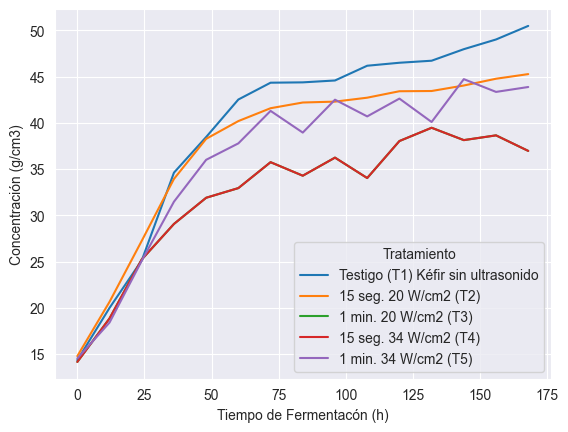

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt


data_long = pd.melt(data, id_vars='Tiempo de Fermentacón (h)', var_name='Tratamiento', value_name='Concentración (g/cm3)')

# Plot
sns.lineplot(data=data_long, x='Tiempo de Fermentacón (h)', y='Concentración (g/cm3)', hue='Tratamiento')
plt.savefig("plots/raw_data_plot.png")
plt.show()

In [14]:


data_long["Tratamiento"].value_counts()

Tratamiento
Testigo (T1) Kéfir sin ultrasonido    15
15 seg. 20 W/cm2 (T2)                 15
1 min. 20 W/cm2 (T3)                  15
15 seg. 34 W/cm2 (T4)                 15
1 min. 34 W/cm2 (T5)                  15
Name: count, dtype: int64

In [11]:
data_long.head(20)

,Tiempo de Fermentacón (h),Tratamiento,Concentración (g/cm3)
0,0,Testigo (T1) Kéfir sin ultrasonido,14.326143
1,12,Testigo (T1) Kéfir sin ultrasonido,19.984467
2,24,Testigo (T1) Kéfir sin ultrasonido,25.117400
3,36,Testigo (T1) Kéfir sin ultrasonido,34.613600
4,48,Testigo (T1) Kéfir sin ultrasonido,38.470333
5,60,Testigo (T1) Kéfir sin ultrasonido,42.527867
6,72,Testigo (T1) Kéfir sin ultrasonido,44.346500
7,84,Testigo (T1) Kéfir sin ultrasonido,44.383200
8,96,Testigo (T1) Kéfir sin ultrasonido,44.586233
9,108,Testigo (T1) Kéfir sin ultrasonido,46.182000


<Axes: xlabel='Tiempo de Fermentacón (h)', ylabel='Concentración (g/cm3)'>

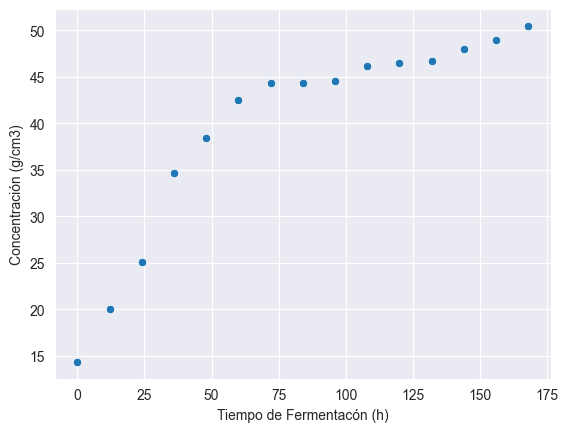

In [13]:
no_treatment = data_long["Tratamiento"]=="Testigo (T1) Kéfir sin ultrasonido"
sns.scatterplot(data=data_long[no_treatment], x='Tiempo de Fermentacón (h)', y='Concentración (g/cm3)')


In [12]:
df = data_long[no_treatment]

df = df.rename(columns={"Tiempo de Fermentacón (h)":"time","Concentración (g/cm3)":"solution"})

df = df[["time","solution"]]

df.to_csv("kefir.csv",index=False)

In [14]:
!ls

0.0_preprocesamiento_datos.ipynb kefir.csv
ajustes_intentos_manuales.ipynb  plots
jupyter_book_installation.ipynb
